# Evolución histórica de Inversión Extranjera Directa en el periodo de tiempo 2002-2026 por trimestres

La Inversión Extranjera Directa (IED) es la cantidad de dinero que ingresó en el pais como inversión por parte de extranjeros. La fuente que se tomará es del Banco de la República y los datos correspondientes se pueden encontrar en https://suameca.banrep.gov.co/estadisticas-economicas-back/reporte-dv.html?path=ied_por_actividad_economica. El análisis es muy sencillo, y nace por preguntarse qué gobierno ha atraído más inversión extranjera.

El flujo de trabajo será el siguiente.

1. Mostrar la evolución temporal de los datos en crudo dados por el BanRep, los cuales están en dolares.

2. Hacer una corrección sencilla por IPC ya que, como es de común conocimiento, el dinero se devalua por inflación, y esto permite comparar justamente. En este caso, como los datos están en millones de dolares, se usará el IPC de Estados Unidos. Específicamente, el *Consumer Price Index for All Urban Consumers* gracias al Federal Reserve Bank of ST.LOUIS. Los datos de la evolución temporal pueden ser encontrados en https://fred.stlouisfed.org/series/CPIAUCSL.

3. Sumar el valor corregido de todos los trimestres de cada periodo presidencial para poder comparar el neto que recibió el pais en los diferentes gobiernos. Como el último dato que reporta el banrep es el primer trimestre del 2026, una comparación justa es tomar el periodo definido desde el trimestre en que se posesionaron (el 7 de agosto corresponde al tercer trimestre) hasta el primer trimestre del año en que terminaron su mandato. Por ejemplo, Uribe en su primer mandato se posesionó el 7 de agosto de 2002 y terminó su primer mandato en el año 2006. Esto quiere decir que el neto de su gobierno se tomará como el que corresponde al periodo 3 trimestre 2002 - 1 trimestre 2006.

Para corregir por inflación, se seguirá la siguiente relación:

$$IED_{real}(t) = IED_{nominal} \left( \frac{\text{IPC final o de referencia}} {\text{IPC (t)}} \right)$$

Como se puede observar, los datos del BanRep están en trimestres, y los del IPC están mensuales. Para usar la relación, se necesita un dato de IPC por cada valor de IED, por lo que se tomará el IPC promedio de cada trimestre. Adicionalmente, el IPC de referencia se seleccionó como el último disponible del último año vencido, es decir el correspondientre al cuatro trimestre del 2025.


En ese orden de ideas, se importan los datos

In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/2_Inversion_Extranjera_Directa_en_Colombia_(IED)_por_actividad_economica_trimestral_iqy.csv')

# Rename the 'Valor' column to 'IED nominal'
df = df.rename(columns={'Valor': 'IED nominal'})

# Display the first 5 rows of the DataFrame
display(df.head())

,Fecha sistema,Unidad de medida y moneda,Tipo de inversión,Orden actividad,Actividad económica,Fecha (Año),Orden trimestre,Trimestre,Estado de la información,IED nominal
0,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,1,Q4,Definitivo,247.809632
1,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,2,Q3,Definitivo,155.775578
2,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,3,Q2,Definitivo,125.392622
3,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,4,Q1,Definitivo,249.320242
4,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1997,1,Q4,Definitivo,7.627212


Se le asigna una fecha específica a cada trimestre, en este caso se seleccionó el primer día de cada trimestre. Esto tiene como fin asignar un punto en la escala temporal para graficar.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map quarters to months (start of quarter for consistency with CPI data)
quarter_to_month = {'Q1': 1, 'Q2': 4, 'Q3': 7, 'Q4': 10}

# Create a new 'Fecha_Trimestre' column combining 'Fecha (Año)' and 'Trimestre'
df['Fecha_Trimestre'] = df['Fecha (Año)'].astype(str) + '-' + df['Trimestre'].map(quarter_to_month).astype(str).str.zfill(2) + '-01'

# Convert to datetime objects. We set day to 1 to simplify, as we are working with quarters.
df['Fecha_Trimestre'] = pd.to_datetime(df['Fecha_Trimestre'], format='%Y-%m-%d')

# Sort the DataFrame by the new datetime column
df = df.sort_values(by='Fecha_Trimestre').reset_index(drop=True)

# Display the updated DataFrame with the new date column
display(df.head())

,Fecha sistema,Unidad de medida y moneda,Tipo de inversión,Orden actividad,Actividad económica,Fecha (Año),Orden trimestre,Trimestre,Estado de la información,IED nominal,Fecha_Trimestre
0,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,7.0,Construcción,1996,4,Q1,Definitivo,-2.270110,1996-01-01
1,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,4.0,Explotación de minas y canteras (incluye carbón),1996,4,Q1,Definitivo,21.364108,1996-01-01
2,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,6.0,"Electricidad, gas y agua",1996,4,Q1,Definitivo,53.806102,1996-01-01
3,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,4,Q1,Definitivo,249.320242,1996-01-01
4,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,9.3,Total actividades económicas,1996,4,Q1,Definitivo,539.878180,1996-01-01


Se cargan los datos de IPC de Estados Unidos

In [3]:
# Load the CSV file into a DataFrame
df_cpi = pd.read_csv('/content/CPIAUCSL.csv')
# Display the first 5 rows of the DataFrame
display(df_cpi.head())

,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


Se organiza por trimestres, como el promedio de cada uno

In [4]:
# Convert 'observation_date' column to datetime objects in df_cpi
df_cpi['observation_date'] = pd.to_datetime(df_cpi['observation_date'])

# Rename 'CPIAUCSL' to 'CPI' for consistency
df_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)

# Set 'observation_date' as the index for resampling
df_cpi.set_index('observation_date', inplace=True)

# Resample monthly CPI to quarterly by taking the mean of months in the quarter (Quarter Start frequency)
cpi_quarterly = df_cpi.resample('QS').mean()
cpi_quarterly.index.name = 'Fecha_Trimestre_CPI'

# Filter CPI data from 1996 onwards
cpi_quarterly = cpi_quarterly[cpi_quarterly.index.year >= 1996]

# Reset index to make 'Fecha_Trimestre_CPI' a regular column for merging
cpi_quarterly = cpi_quarterly.reset_index()

display(cpi_quarterly.head())

,Fecha_Trimestre_CPI,CPI
0,1996-01-01,155.066667
1,1996-04-01,156.400000
2,1996-07-01,157.300000
3,1996-10-01,158.666667
4,1997-01-01,159.633333


Se junta todo en el mismo dataframe

In [5]:
# Merge CPI data into df
# Ensure df has unique Fecha_Trimestre values for merging (if not already unique due to groupby)
df_merged = pd.merge(df, cpi_quarterly, left_on='Fecha_Trimestre', right_on='Fecha_Trimestre_CPI', how='left')

# Drop the redundant CPI date column
df_merged.drop(columns=['Fecha_Trimestre_CPI'], inplace=True)

# Display the first few rows with the new 'CPI' column
display(df_merged.head())

,Fecha sistema,Unidad de medida y moneda,Tipo de inversión,Orden actividad,Actividad económica,Fecha (Año),Orden trimestre,Trimestre,Estado de la información,IED nominal,Fecha_Trimestre,CPI
0,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,7.0,Construcción,1996,4,Q1,Definitivo,-2.270110,1996-01-01,155.066667
1,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,4.0,Explotación de minas y canteras (incluye carbón),1996,4,Q1,Definitivo,21.364108,1996-01-01,155.066667
2,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,6.0,"Electricidad, gas y agua",1996,4,Q1,Definitivo,53.806102,1996-01-01,155.066667
3,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,4,Q1,Definitivo,249.320242,1996-01-01,155.066667
4,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,9.3,Total actividades económicas,1996,4,Q1,Definitivo,539.878180,1996-01-01,155.066667


Ahora que se tiene un valor de IED nominal y un valor de IPC para cada trimestre, se calcula el valor de IED real

In [6]:
# Choose a base year for inflation adjustment (e.g., Q1 2022)
# Convert 'Fecha_Trimestre' to datetime objects if not already
df_merged['Fecha_Trimestre'] = pd.to_datetime(df_merged['Fecha_Trimestre'])

# Find the CPI value for the chosen base quarter (2022-01-01)
# We need to make sure the base date exists in our merged data's Fecha_Trimestre
base_date = pd.to_datetime('2025-10-01')

# Filter df_merged to get the CPI value for the base date
base_year_cpi_row = df_merged[df_merged['Fecha_Trimestre'] == base_date].head(1)

# Check if base_year_cpi_row is empty, indicating the base date might not be in the filtered data
if not base_year_cpi_row.empty:
    base_year_cpi = base_year_cpi_row['CPI'].iloc[0]
    # Calculate the inflation adjusted (real) IED
    df_merged['IED real'] = (df_merged['IED nominal'] / df_merged['CPI']) * base_year_cpi
    print(f"IED real calculated using base CPI from {base_date.strftime('%Y-%m-%d')}: {base_year_cpi:.2f}")
else:
    print(f"Warning: Base date {base_date.strftime('%Y-%m-%d')} not found in 'Fecha_Trimestre' of merged data. 'IED real' not calculated.")
    df_merged['IED real'] = pd.NA # Assign a placeholder if calculation isn't possible

# Display the first few rows with the new 'IED real' column
display(df_merged.head())

IED real calculated using base CPI from 2025-10-01: 325.55


,Fecha sistema,Unidad de medida y moneda,Tipo de inversión,Orden actividad,Actividad económica,Fecha (Año),Orden trimestre,Trimestre,Estado de la información,IED nominal,Fecha_Trimestre,CPI,IED real
0,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,7.0,Construcción,1996,4,Q1,Definitivo,-2.270110,1996-01-01,155.066667,-4.765870
1,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,4.0,Explotación de minas y canteras (incluye carbón),1996,4,Q1,Definitivo,21.364108,1996-01-01,155.066667,44.851813
2,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,6.0,"Electricidad, gas y agua",1996,4,Q1,Definitivo,53.806102,1996-01-01,155.066667,112.960544
3,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,1.0,Sector petrolero,1996,4,Q1,Definitivo,249.320242,1996-01-01,155.066667,523.422979
4,03/06/2026 15:12:07,Millones - Dólar estadounidense,Inversión Extranjera Directa en Colombia,9.3,Total actividades económicas,1996,4,Q1,Definitivo,539.878180,1996-01-01,155.066667,1133.420390


Esta gráfica muestra los datos sin corregir, que permite ver la evolución por sector económico. Se avanzará en la corrección solamente con el valor total (es decir, se suman todas las actividades económicas)

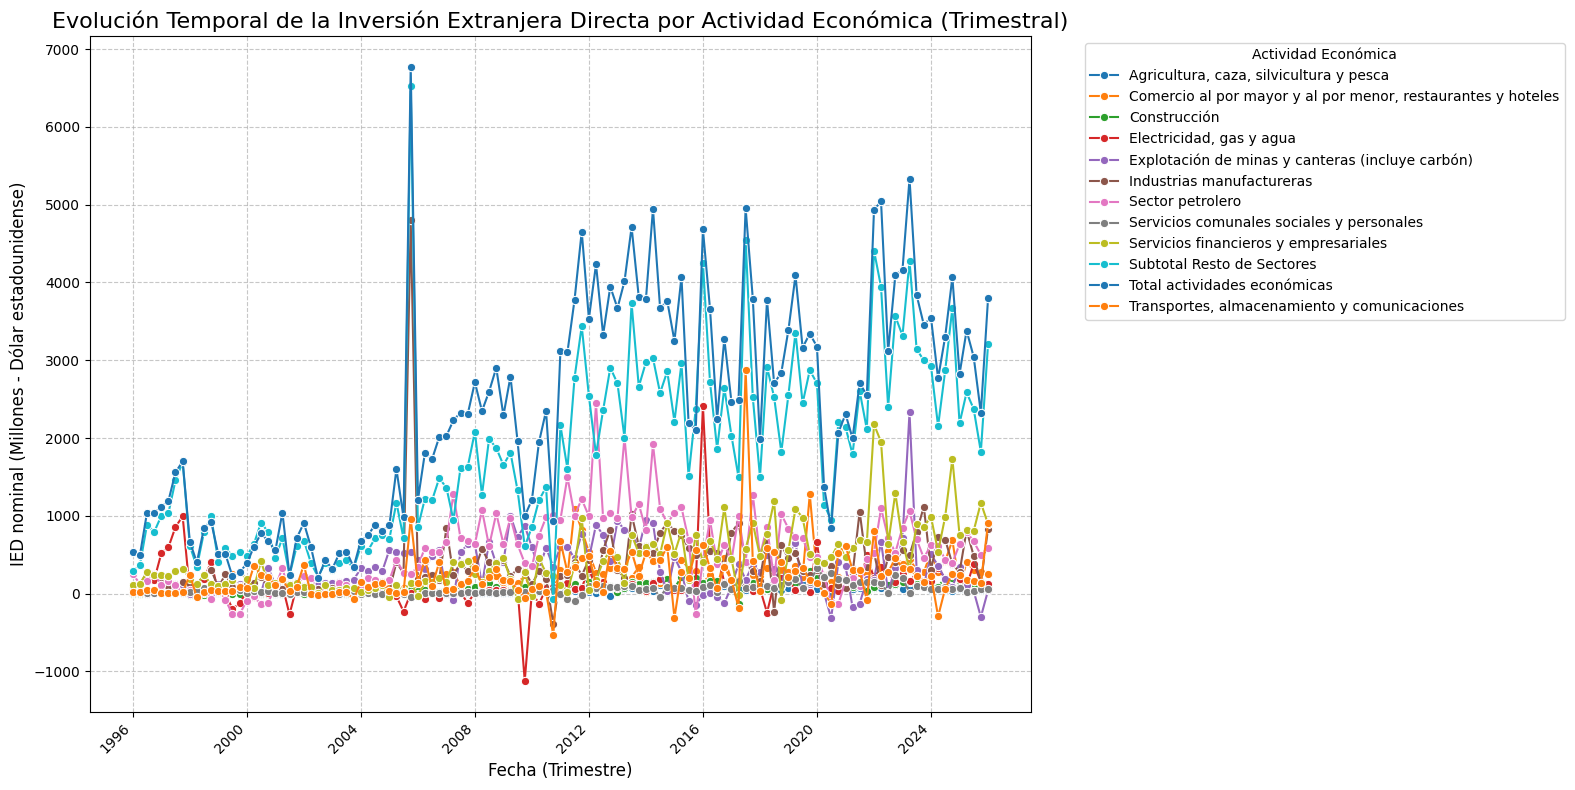

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate the data by 'Fecha_Trimestre' and 'Actividad económica', summing the 'IED nominal'
agg_df = df.groupby(['Fecha_Trimestre', 'Actividad económica'])['IED nominal'].sum().reset_index()

# Plot the time series
plt.figure(figsize=(16, 8))
sns.lineplot(data=agg_df, x='Fecha_Trimestre', y='IED nominal', hue='Actividad económica', marker='o', palette='tab10')

plt.title('Evolución Temporal de la Inversión Extranjera Directa por Actividad Económica (Trimestral)', fontsize=16)
plt.xlabel('Fecha (Trimestre)', fontsize=12)
plt.ylabel('IED nominal (Millones - Dólar estadounidense)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Actividad Económica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ahora sí, solo se grafica por total de actividades economicas con los datos corregidos

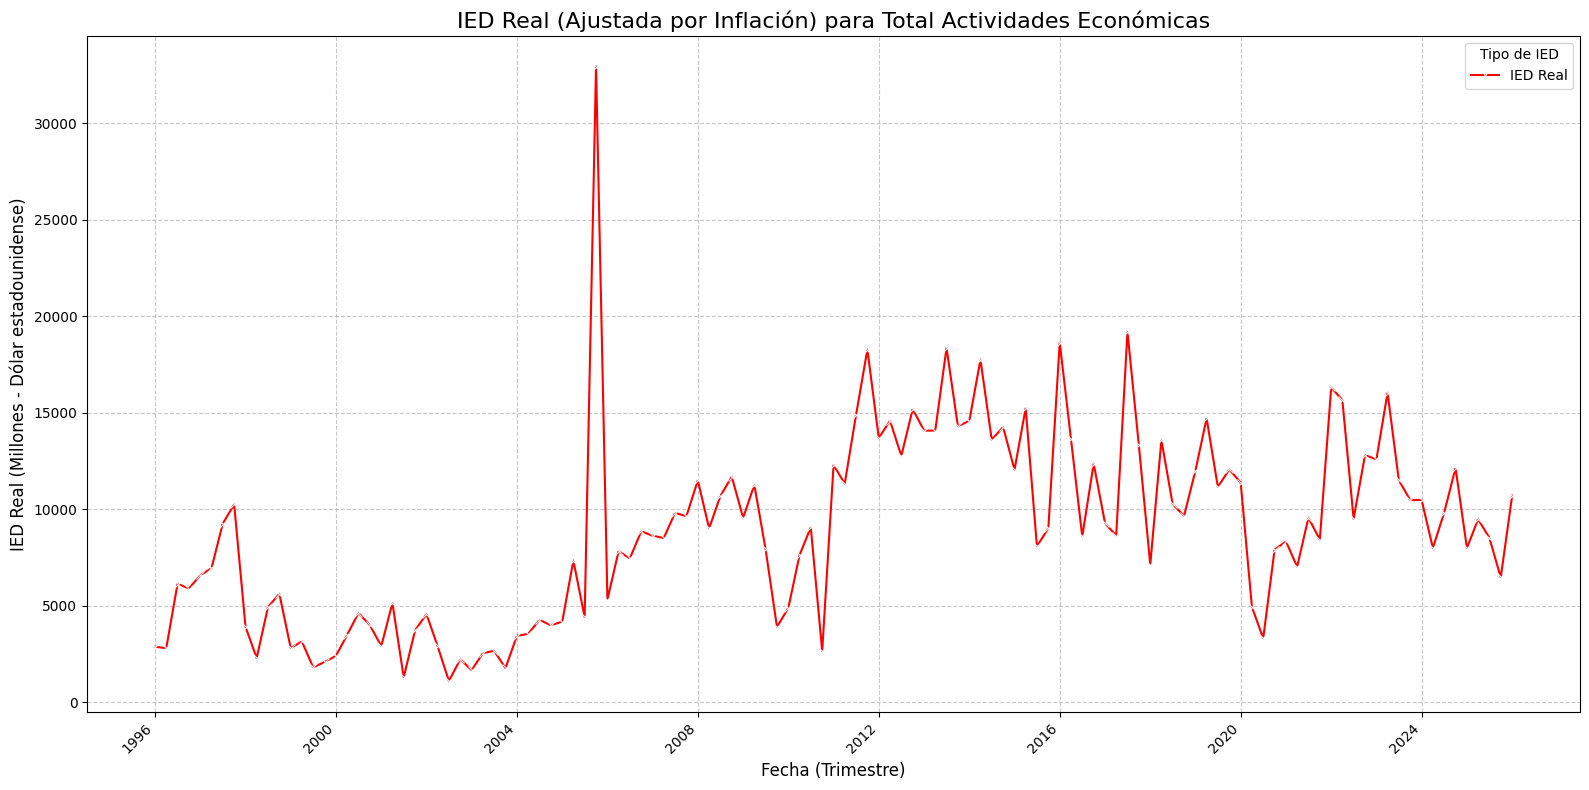

In [8]:
# Aggregate the 'IED real' for all activities by 'Fecha_Trimestre'
total_activities_real_ied_df = df_merged.groupby('Fecha_Trimestre')['IED real'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(data=total_activities_real_ied_df, x='Fecha_Trimestre', y='IED real', label='IED Real', marker='x', color='red')

plt.title('IED Real (Ajustada por Inflación) para Total Actividades Económicas', fontsize=16)
plt.xlabel('Fecha (Trimestre)', fontsize=12)
plt.ylabel('IED Real (Millones - Dólar estadounidense)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Tipo de IED')
plt.tight_layout()
plt.show()

Finalmente, se suman todos los trimestres por cada periodo presidencial. Como el último dato de banrep es del primer trimestre de 2026, se deben comparar los mismos rangos de tiempo entre mandatos. Este se definió como: 3 trimestre del año en que se posesionaron - primer trimestre del año en que dejaron el mandato.

In [9]:
mandates = {
    'Neto mandato 1 de Uribe': ('2002-07-01', '2006-01-01'),
    'Neto mandato 2 de Uribe': ('2006-07-01', '2010-01-01'),
    'Neto mandato 1 de Santos': ('2010-07-01', '2014-01-01'),
    'Neto mandato 2 de Santos': ('2014-07-01', '2018-01-01'),
    'Neto mandato Duque': ('2018-07-01', '2022-01-01'),
    'Neto mandato Petro': ('2022-07-01', '2026-01-01')
}

real_ied_results = {}

for mandate_name, (start_date_str, end_date_str) in mandates.items():
    start_date = pd.to_datetime(start_date_str)
    end_date = pd.to_datetime(end_date_str)

    # Filter the DataFrame for the current mandate period
    mandate_df = total_activities_real_ied_df[
        (total_activities_real_ied_df['Fecha_Trimestre'] >= start_date) &
        (total_activities_real_ied_df['Fecha_Trimestre'] <= end_date)
    ]

    # Calculate the sum of 'IED real' for the period
    # This approximates the area under the curve by summing the quarterly values.
    net_ied_real = mandate_df['IED real'].sum()
    real_ied_results[mandate_name] = net_ied_real

# Display the results
print("IED Real Net Values per Mandate (Sum of Quarterly IED Real):")
for mandate, value in real_ied_results.items():
    print(f"{mandate}: {value:,.2f}")

IED Real Net Values per Mandate (Sum of Quarterly IED Real):
Neto mandato 1 de Uribe: 81,414.54
Neto mandato 2 de Uribe: 133,341.98
Neto mandato 1 de Santos: 200,116.75
Neto mandato 2 de Santos: 183,035.08
Neto mandato Duque: 147,058.91
Neto mandato Petro: 156,532.02


Esto se grafica en un diagrama de barras

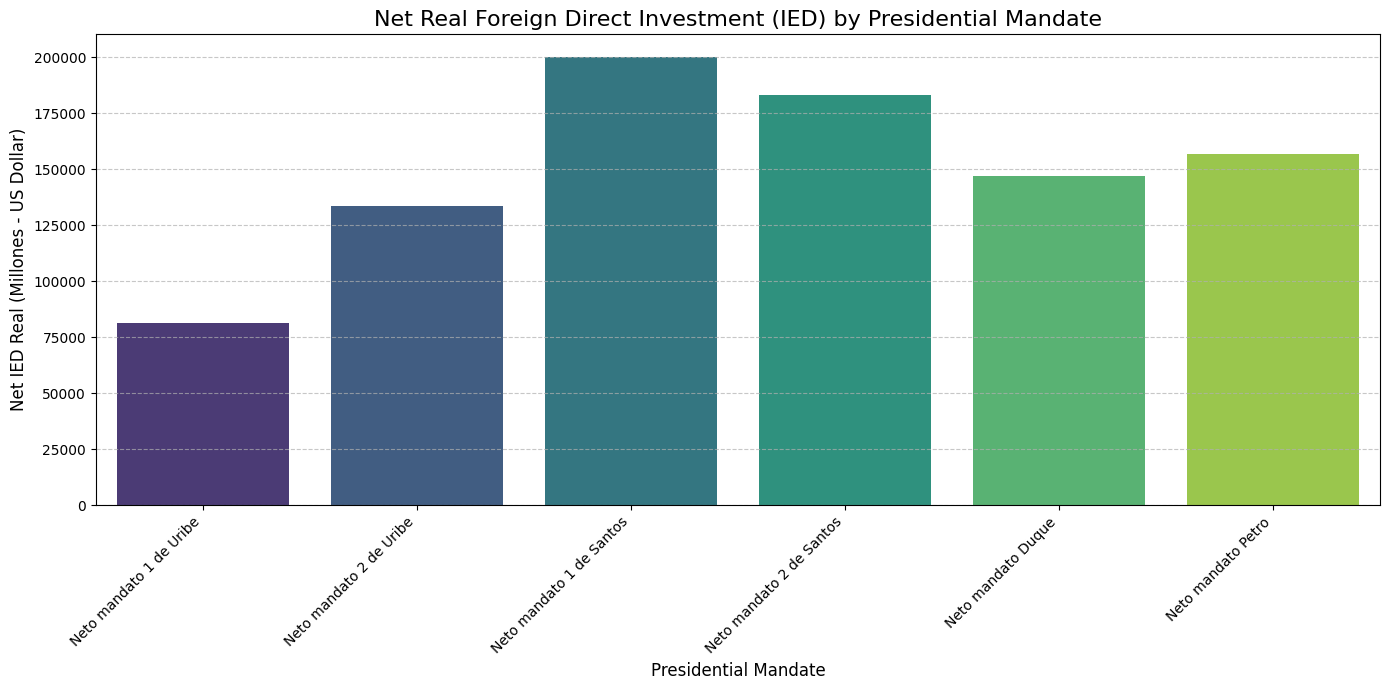

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the results dictionary to a Pandas DataFrame for plotting
ied_mandate_df = pd.DataFrame(real_ied_results.items(), columns=['Mandate', 'Net IED Real'])

# Sort the mandates chronologically for better visualization if desired, or keep as is
# For this specific data, they are already in chronological order by key insertion.

plt.figure(figsize=(14, 7))
sns.barplot(x='Mandate', y='Net IED Real', data=ied_mandate_df, palette='viridis', hue='Mandate', legend=False)

plt.title('Net Real Foreign Direct Investment (IED) by Presidential Mandate', fontsize=16)
plt.xlabel('Presidential Mandate', fontsize=12)
plt.ylabel('Net IED Real (Millones - US Dollar)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Estos resultados indican que Uribe atrajo más inversión en su segundo mandato. Santos atrajo más en su primer mandato. Duque Atrajo más que Uribe en cualquiera de sus dos mandatos. **Petro atrajo más que Uribe en cualquiera de sus dos mandatos y que Duque en su único mandato.** Y por último, que el presidente que más ha atraído inversión en la historia reciente del pais ha sido Santos en su primer mandato.